# A Deep Dive into Bayesian Model Comparison with BayesFlow

_Author: Jerry M. Huang_

In this notebook, we take a deep dive into Bayesian model comparison by demonstrating the `ModelComparisonWorkflow` in BayesFlow. We will demonstrate two capabilities that the workflow has to offer: Bayes factor (BF) and posterior model probability (PMP) estimation.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numba import njit

import bayesflow as bf

from bayesflow.workflows import ModelComparisonWorkflow
import bayesflow.diagnostics.plots as bf_plots

In [22]:
rng = np.random.default_rng(seed=2026)

## Two Families of Scoring Rules

At the heart of any model comparison workflow is a **scoring rule** — a loss function that determines what exactly the network learns to predict. BayesFlow offers two distinct families of scoring rules, and the choice between them is not a mere implementation detail: it determines what question you are asking of your data.

### Scoring rules to estimate posterior model probabilities (PMPs)

PMP scoring rules answer the question: *"Given this dataset, and assuming one of the candidate models is true, how likely is each candidate model to be the true model?"*

The network is trained to output the vector of posterior model probabilities $P(\mathcal{M}_k \mid \mathbf{x})$ given data $\mathbf{x}$. It returns a proper categorical probability distribution over models, exactly as in a classification problem. 

Under a uniform prior $P(\mathcal{M}_k)$, PMPs equal the softmax-normalized marginal likelihoods. The outputs can be used for model selection: picking the most probable model is Bayes-optimal under 0–1 loss, and the probabilities carry a direct frequentist interpretation. If the network assigns 80% to a model, it should be the true model roughly 80% of the time. This is the **calibration** property. In approximate infernce, calibration is not a given. Thus, checking calibration represents an important diagnostic step in your workflow.

PMP scoring rules are the right choice when you want a fast, interpretable ranking of models/hypotheses or when downstream decisions need graded model uncertainty. In BayesFlow, we currently support the following PMP scoring rules:

| Class | Loss |
|-------|------|
| `CrossEntropyScore` | Categorical cross-entropy (default) |
| `BrierScore` | Brier score — mean squared error on softmax probabilities |
| `PolynomialScore` | Polynomial scoring rule; `alpha=2` recovers the Brier score |

### Scoring rules to estimate Bayes factors

BF scoring rules answer a different question: *"How much more evidence does the data provide for one model over another?"*

The network outputs **log Bayes factors** $\log \mathrm{BF}_{k,\mathrm{ref}} = \log p(\mathbf{x} \mid \mathcal{M}_k) - \log p(\mathbf{x} \mid \mathcal{M}_\mathrm{ref})$ relative to a fixed reference model $\mathcal{M}_\mathrm{ref}$. Crucially, Bayes factors are invariant to the model prior $p(\mathcal{M}_k)$. They depend only on the marginal likelihoods, not on how likely you thought each model was before seeing the data. This makes them a popular choice for hypothesis testing: a $\log \mathrm{BF} = 3$ is a statement about evidence strength, interpretable regardless of the prior over models. Bayes factors also **compose**: the log BF for any competing pair of models follows immediately from the reference-anchored network outputs via subtraction.

Estimating Bayes factors is usually harder than estimating probabilities, since the network must recover a real-valued ratio of often very different likelihoods. Thus, several rule variants exist with different numerical properties.

| Class | Notes |
|-------|-------|
| `ExponentialScore()` | Baseline BF rule; default α=1 |
| `ExponentialScore(alpha=α)` | Scaled exponential; α controls output scale, recovers log BFs via ×α |
| `ExponentialScore(leaky=α)` | Leaky transform before exp; better recovery on extreme BFs |
| `LogisticScore()` | Softplus-based; numerically stable alternative |
| `LogisticScore(alpha=α)` | Power-logistic; raises softplus term to power α; tunes sharpness |

### How the choice shapes the workflow

The scoring rule you pass to `ModelComparisonWorkflow` propagates through the entire pipeline automatically. As a user, all you have to worry about is choosing a scoring rule that aligns with your target quantity for model comparison (PMPs or BFs).

## Simple Example: Normal-Normal Model

To illustrate, we start with the simplest possible setting. We will compare four Gaussian models that differ only in their prior on the mean. The observation model is identical across all four, and the conjugate structure gives **closed-form marginal likelihoods**, so ground-truth log Bayes factors are available for every test dataset.

We will train the network with a Bayes factor scoring rule, then immediately check how well it recovers the analytic truth using `bayes_factor_recovery`.

### Model specification

The four models are intentionally minimal: they share the same observation model:

\begin{equation}
x_i \mid \mu \sim \mathcal{N}(\mu, 1) 
\end{equation}

and differ only in the prior placed on $\mu$ which varies its mean and width.

| Model | Prior |
|-------|-------|
| $M_1$ (ref.) | $\mu \sim \mathcal{N}(0,\ 1)$ — wide, centered |
| $M_2$ | $\mu \sim \mathcal{N}(0,\ 0.25)$ — narrow, centered |
| $M_3$ | $\mu \sim \mathcal{N}(1,\ 1)$ — wide, shifted |
| $M_4$ | $\mu \sim \mathcal{N}(1,\ 0.25)$ — narrow, shifted |

In [23]:
N_OBS = 50  # observations per dataset

# (mu0, tau) for each model's prior mu ~ N(mu0, tau^2)
PRIOR_PARAMS = [
    (0.0, 1.0),   # M1 (ref): wide, centered
    (0.0, 0.5),   # M2: narrow, centered
    (1.0, 1.0),   # M3: wide, shifted
    (1.0, 0.5)    # M4: narrow, shifted
]

In [24]:
def prior_1():
    return dict(mu=rng.normal(loc=0.0, scale=1.0))

def prior_2():
    return dict(mu=rng.normal(loc=0.0, scale=0.5))

def prior_3():
    return dict(mu=rng.normal(loc=1.0, scale=1.0))

def prior_4():
    return dict(mu=rng.normal(loc=1.0, scale=0.5))

def likelihood(mu, **kwargs):
    x = np.random.normal(loc=mu, scale=1.0, size=(N_OBS, 1)).astype(np.float32)
    return dict(x=x)

# Bundling everything together
simulators = [
    bf.make_simulator([prior_1, likelihood]),
    bf.make_simulator([prior_2, likelihood]),
    bf.make_simulator([prior_3, likelihood]),
    bf.make_simulator([prior_4, likelihood])
]

Because $\sigma=1$ is fixed and each prior is conjugate Gaussian, integrating out $\mu$ gives a closed-form marginal likelihood:

$$
\log p(\mathbf{x} \mid M_k) =
  -\frac{n}{2}\log(2\pi)
  - \frac{1}{2}\log\!\left(1 + n\tau_k^2\right)
  - \frac{1}{2}\!\left[
      \sum_i x_i^2
      + \frac{\mu_{0,k}^2}{\tau_k^2}
      - \frac{\displaystyle\left(n\bar{x} + \frac{\mu_{0,k}}{\tau_k^2}\right)^2}{\displaystyle n + \frac{1}{\tau_k^2}}
    \right]
$$

Ground-truth log Bayes factors $\log \mathrm{BF}_{k,1} = \log p(\mathbf{x}\mid M_k) - \log p(\mathbf{x}\mid M_1)$ are computed analytically per dataset and used to validate the network via `bayes_factor_recovery`.

In [25]:
def log_marginal_likelihood(x, mu0, tau):
    """Analytic log marginal likelihood: x_i | mu ~ N(mu, 1), mu ~ N(mu0, tau^2)."""
    n = len(x)
    x_bar = np.mean(x)
    ss = np.sum(x ** 2)
    prec_prior = 1.0 / tau ** 2
    B = n * x_bar + mu0 * prec_prior
    A = n + prec_prior
    return (
        -n / 2 * np.log(2 * np.pi)
        - 0.5 * np.log(1.0 + n * tau ** 2)
        - 0.5 * (ss + mu0 ** 2 * prec_prior - B ** 2 / A)
    )


def compute_true_log_bfs(test_data, reference=0):
    """Compute analytic log BFs of shape (B, num_models-1) from simulated test data."""
    x_batch = test_data["x"]
    B = x_batch.shape[0]
    mu0_ref, tau_ref = PRIOR_PARAMS[reference]
    competing = [k for k in range(len(PRIOR_PARAMS)) if k != reference]
    log_bfs = np.zeros((B, len(competing)))
    for i, k in enumerate(competing):
        mu0_k, tau_k = PRIOR_PARAMS[k]
        for b in range(B):
            x = x_batch[b, :, 0].astype(np.float64)
            log_bfs[b, i] = (
                log_marginal_likelihood(x, mu0_k, tau_k)
                - log_marginal_likelihood(x, mu0_ref, tau_ref)
            )
    return log_bfs

### Workflow setup

The only addition compared to `BasicWorkflow` is the `scoring_rules` argument. Here we use `ExponentialScore`, the baseline Bayes factor rule. Swapping in `ExponentialScore(leaky=2.0)` or any other BF rule requires no other changes to the workflow.

There is no need to pass `inference_variables`. Within `ModelComparisonWorkflow`, they will automatically be named `model_indices` if no custom `Adapter` is provided.

In [26]:
workflow = ModelComparisonWorkflow(
    simulator=simulators,
    summary_variables="x",
    summary_network=bf.networks.SetTransformer(),
    scoring_rules=bf.scoring_rules.ExponentialScore(),
    standardize="summary_variables"
)

Training uses the same interface as any other BayesFlow workflow. Below, we demonstrate online training, as our models are trivial to simulate.

In [27]:
history = workflow.fit_online(
    epochs=10,
    num_batches_per_epoch=100,
    batch_size=32,
)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 2.3476 - scoring_rule/inference_scoring_rule: 2.3476
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.3448 - scoring_rule/inference_scoring_rule: 2.3448
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.3389 - scoring_rule/inference_scoring_rule: 2.3389
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.1760 - scoring_rule/inference_scoring_rule: 2.1760
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.1896 - scoring_rule/inference_scoring_rule: 2.1896
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.4623 - scoring_rule/inference_scoring_rule: 2.4623
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.5191 - scoring_rule/inference_scoring_rule: 2.5191
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.1144 - scoring_rule/inference_scoring_rule: 2.1144
Epoch 9/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.9393 - scoring_rule/inference_scor

INFO:bayesflow:Training completed in 9.40 seconds.


We can inspect how our `ModelComparisonWorkflow` performs by looking at the default diagnostics:

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Estimation completed in 0.03 seconds.
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode


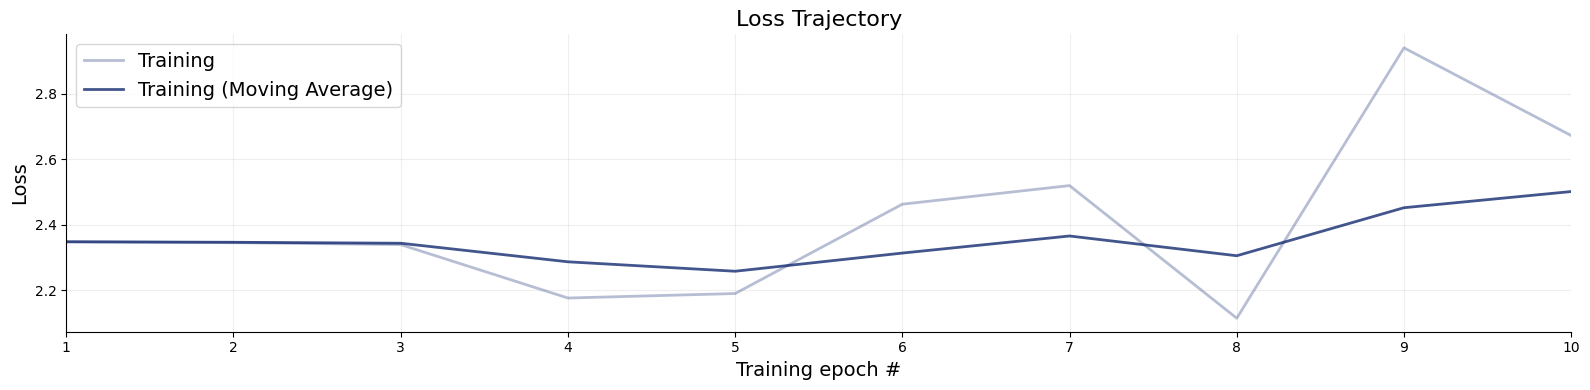

INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode


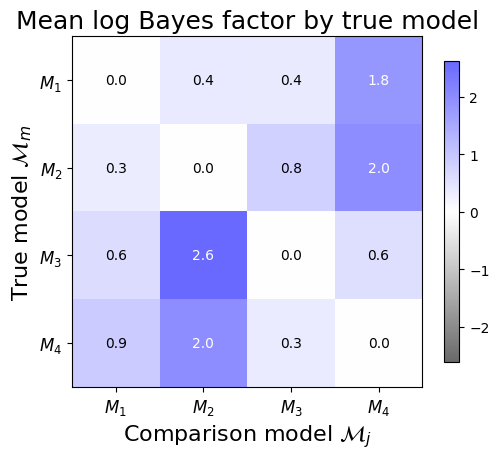

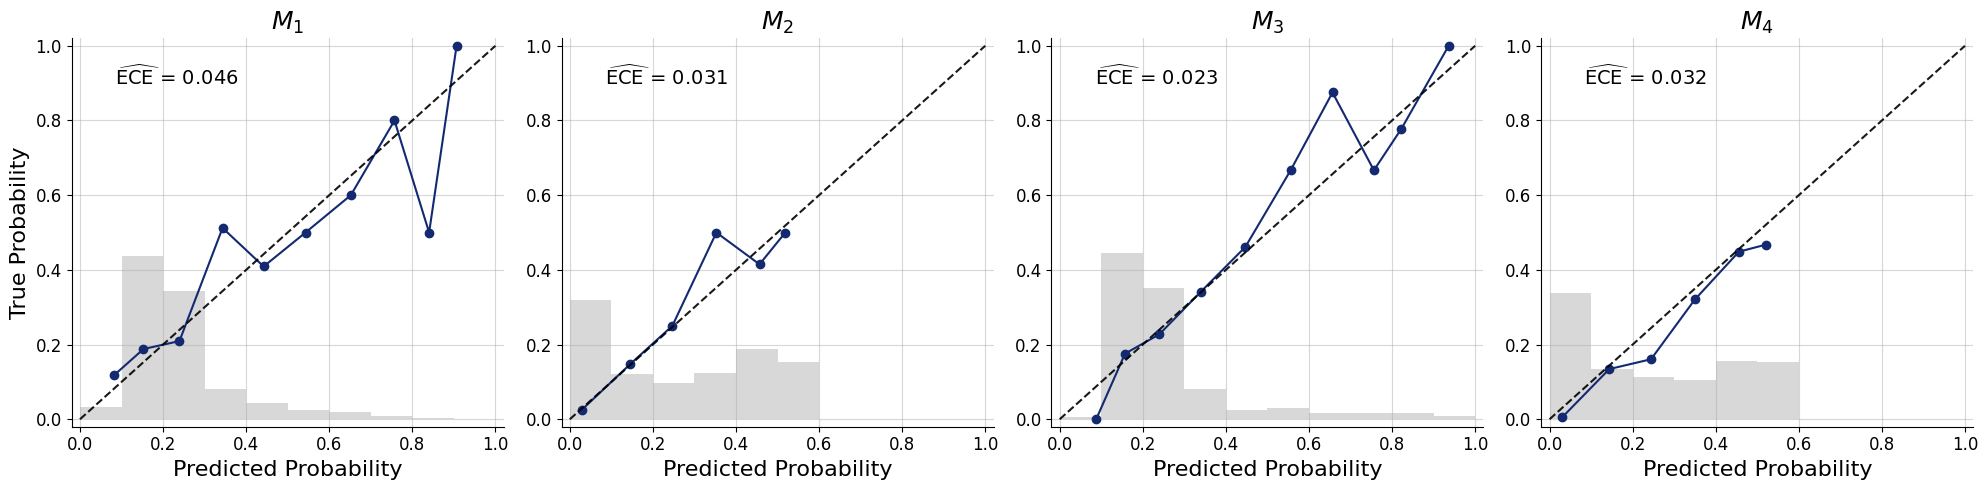

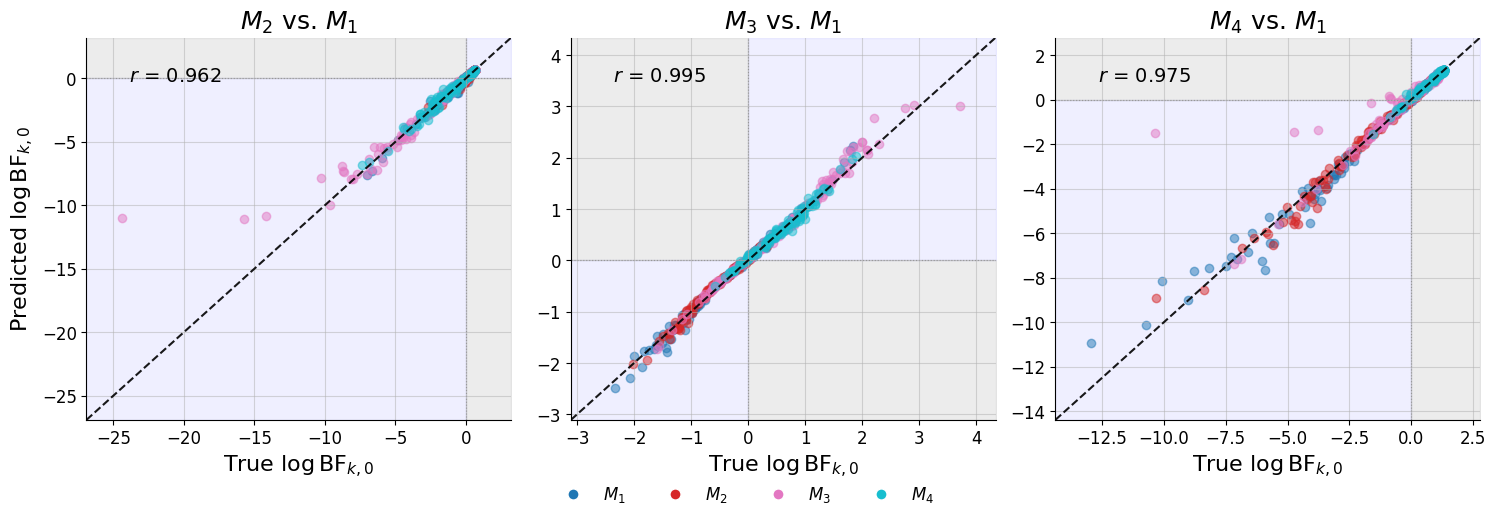

In [28]:
figures = workflow.plot_default_diagnostics(test_data=500, true_log_bfs_fn=compute_true_log_bfs)

Because we supplied `true_log_bfs_fn`, the workflow produces **four** diagnostic plots for BF rules:

- **Loss trajectory** — the training loss of the Bayes factor scoring rule (here `ExponentialScore`) across epochs, shown both as the raw per-epoch value and as an exponential moving average. Unlike a cross-entropy loss, the value of a BF scoring rule is not bounded in $[0, \log M]$ and has no absolute interpretation, so only its *trend* is meaningful. Because the exponential rule targets a real-valued likelihood ratio, the loss is inherently noisy from epoch to epoch — a single batch can be dominated by a few datasets with extreme Bayes factors. In addition, our models are simple enough for the loss trajectory to flatten quickly.

- **Calibration curves** — reliability diagrams that assess whether the PMPs derived from the network's log BFs are trustworthy as probability estimates. Each panel bins the predicted PMP $\hat{P}(\mathcal{M}_k \mid \mathbf{x})$ on the x-axis and shows the empirical fraction of datasets in that bin that truly came from $\mathcal{M}_k$ on the y-axis; the ECE is the weighted mean absolute deviation from the diagonal. A well-calibrated network tracks the diagonal closely. Curves bowing above indicate underconfidence, curves bowing below indicate overconfidence — and either can occur independently of how sharp the BF recovery looks.

- **Pairwise log Bayes factors** — heatmap of the mean $\log \mathrm{BF}_{m,j}$ stratified by true model. Each row $m$ shows the average predicted log BF favoring model $m$ over each competitor $j$, averaged over all test datasets truly generated from $\mathcal{M}_m$. Diagonal entries are zero by construction ($\mathrm{BF}_{m,m} = 1$). If the models are easily distinguishable, a well-trained network produces large positive off-diagonal entries in every row, confirming that the predicted evidence consistently favors the correct model over alternatives.

- **Bayes factor recovery** — scatter plot of predicted $\log \mathrm{BF}_{k,0}$ against the analytic truth, colored by the true generating model. Points should cluster tightly around the diagonal. The background is shaded into quadrants by the **sign** of the true and predicted log BF, because the sign is what determines the model-selection decision: a positive $\log \mathrm{BF}$ favors the competing model, a negative one favors the reference. The green quadrants (lower-left and upper-right) are therefore the **agreement** regions, where the true and predicted Bayes factors point to the same model — i.e. the decision is correct — while the red quadrants (upper-left and lower-right) are **disagreement** regions, where the network would select the wrong model. This shading makes decision errors visible at a glance and separates them from mere magnitude errors: a point can sit far from the diagonal yet still land in a green quadrant (right decision, wrong strength), or hug the axes yet cross into red (a sign flip near $\log \mathrm{BF} = 0$, where the evidence is weak anyway). The Pearson correlation $r$ annotated on each panel quantifies overall recovery quality; values close to 1 indicate the network tracks the analytic BF accurately across the full range.

**What do the diagnostics tell us here?** The network recovers the analytic Bayes factors well: $r \approx 0.97$–$0.99$, with points hugging the diagonal inside the green agreement quadrants and the only strays near $\log \mathrm{BF} = 0$, where a sign flip barely matters. Calibration is tight as well (ECE $\approx 0.03$–$0.04$).

The pairwise heatmap adds the substantive reading. Its magnitudes mirror how different the priors are: separations are largest between models that differ in **both** prior location and width ($M_1$ vs. $M_4$, $\approx 2.4$ log units) and smallest between models that differ in only a **single** aspect — $M_1$ vs. $M_2$ (same mean, different width, $\approx 0.6$) or $M_1$ vs. $M_3$ (same width, shifted mean, $\approx 0.5$). Detecting a single changed feature from $n = 50$ observations yields only modest evidence, and the network reproduces this faithfully.

Because log Bayes factors uniquely determine posterior model probabilities under a uniform model prior, we can also compute and diagnose PMPs from the BF-trained network. The PMP output `estimate()["model_probs"]` is obtained by applying a softmax over the full pairwise BF matrix. This means the confusion matrix — normally associated with PMP rules — is equally valid for a BF-trained network, and provides a complementary view of decision quality that the BF diagnostics alone do not capture.

The **confusion matrix** shows, for each true generating model, how often the network's top prediction (argmax of the PMPs) agrees with it. Rows are the true model, columns are the predicted model, and diagonal mass indicates correct classification; off-diagonal entries tend to accumulate between structurally similar model pairs.

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Estimation completed in 0.03 seconds.


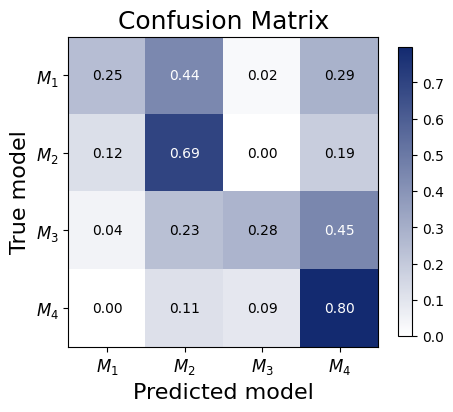

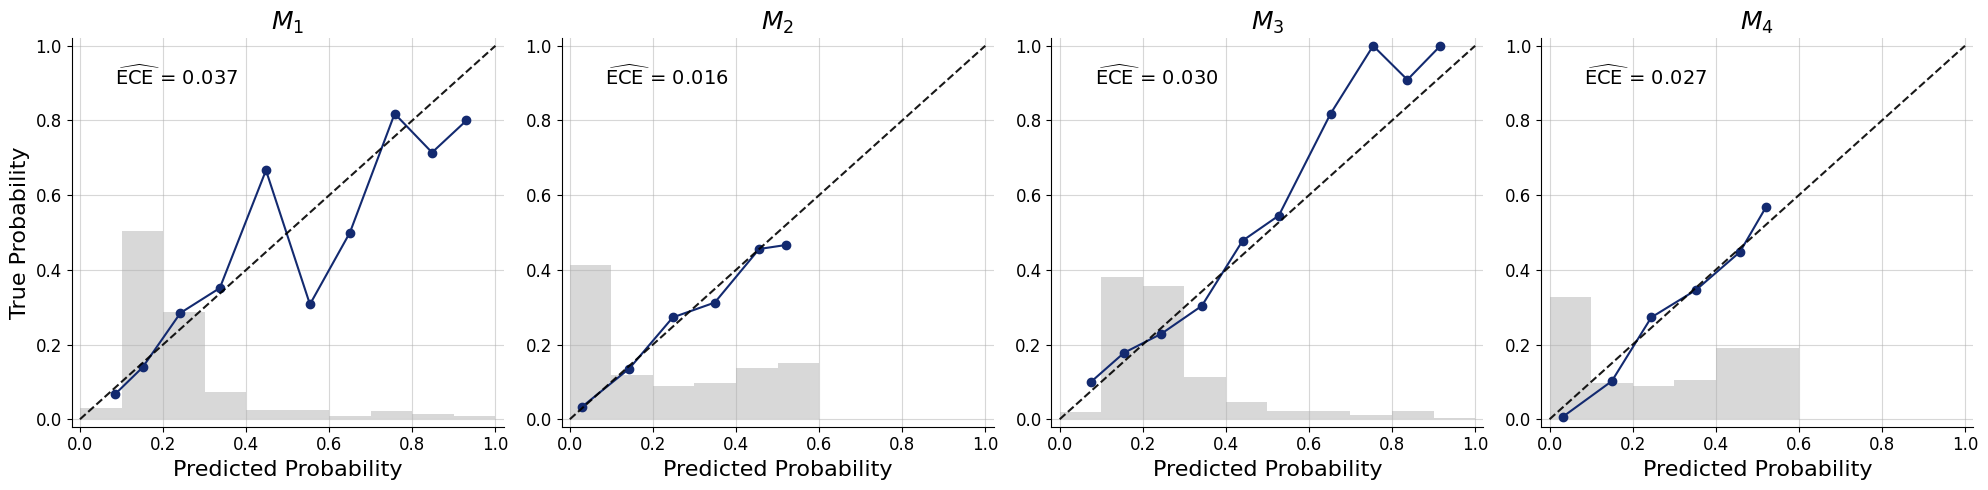

In [29]:
test_data = workflow.simulate(500)
estimates = workflow.estimate(conditions=test_data)

fig_cm = bf_plots.mc_confusion_matrix(
    pred_models=estimates["model_probs"],
    true_models=test_data["model_indices"],
)

fig_cal = bf_plots.mc_calibration(
    pred_models=estimates["model_probs"],
    true_models=test_data["model_indices"],
)

**Is this confusion pattern good or bad?** At first glance the matrix looks sobering: the wide-prior models ($M_1$, $M_3$) are recovered poorly and are most often classified as their narrow-prior counterparts ($M_1 \to M_2$ and $M_3 \to M_4$), while the narrow-prior models ($M_2$, $M_4$) are identified reliably. But this asymmetry is exactly how Bayes-optimal selection among (near-)nested models should behave. It is a property of the problem, not a defect of the network (as seen in its recovery of true BFs). 

The narrow priors are effectively contained within the wide ones: a dataset simulated under $M_1$ whose sample mean happens to land near zero is explained just as well by $M_2$, which concentrates its prior mass there and therefore earns the larger marginal likelihood (i.e., Occam's razor at work). The reverse mistake is accordingly rare ($M_2 \to M_1$ and $M_4 \to M_3$) The magnitudes are also consistent with the pairwise heatmap above: with mean log BFs of only $\approx 0.5$–$0.6$ between single-feature neighbors, the PMPs rarely stray far from uniform, so no classifier, however well trained, could recover the wide-prior models much more often.

The calibration curves make the same point from a different angle: with ECEs of $\approx 0.03$–$0.06$, the predicted probabilities remain truthful, so the "errors" in the confusion matrix are faithfully reported as graded uncertainty rather than hidden behind overconfident labels.

## Real-World Example: GARCH Volatility Models

The normal-normal example gave us a clean sandbox — conjugate structure, closed-form ground truth, fully controlled discrimination difficulty. But the central premise of amortized inference is that the Bayesian workflow can also be applied to much more complex models, even with intractable likelihoods.

We now discriminate between four models from the **Generalized Autoregressive Conditional Heteroscedasticity (GARCH) model family**, the workhorse of volatility modeling in computational finance. All four share the same return-generating mechanism but differ in how they model the evolution of conditional variance: one captures only short-memory shocks (ARCH), one adds persistent volatility clustering (GARCH), one introduces an asymmetric leverage effect (GJR-GARCH), and one allows for heavy-tailed innovations (GARCH-t). These are genuinely hard to tell apart from a finite return series — they are nested or near-nested, and the distinguishing features manifest most clearly under extreme market conditions.

Here we estimate the PMPs directly via a PMP scoring rule. We could equally have estimated Bayes factors via a BF scoring rule: because BayesFlow is fully **simulation-based**, the network never evaluates a likelihood, so *both* families of scoring rules are available whether or not the likelihood — or the marginal likelihood — is analytically tractable.

We nonetheless prefer PMPs here, for three reasons. First, they are exactly the quantity we want — a probability for each of the four models, ready for ranking or selection. Second, their outputs are bounded by the softmax function, making them easier and more stable to learn than a real-valued, potentially large log Bayes factor. This is beneficial because the models we are comparing are near-nested, and the return series is long, where marginal-likelihood ratios can grow extreme. And finally, PMPs can be validated with no ground truth at all, through the confusion matrix and calibration curves. Choosing BFs would forfeit this last advantage: since GARCH marginal likelihoods have no closed form, there would be no ground-truth Bayes factors to feed `bayes_factor_recovery` — though the calibration and pairwise-BF diagnostics would remain available either way.

### Model specification

The four models form a progression of increasing complexity, each adding one structural feature: volatility persistence, an asymmetric leverage effect, and heavy-tailed innovations.

| Model | Key feature |
|-------|-------------|
| ARCH(1) | Short-memory ARCH: volatility shocks decay in one step |
| GARCH(1,1) | Persistent volatility clustering, Gaussian innovations |
| GJR-GARCH(1,1) | Leverage effect: negative shocks inflate variance more |
| GARCH-t | GARCH(1,1) with Student-t innovations; heavier tails |

Here, we unify them into a single simulator that contains all four models as special cases.

In [30]:
@njit
def simulate_garch(omega, alpha, mu, beta, gamma, nu, T, burn_in):
    """JIT-compiled GARCH recursion. nu=inf selects Gaussian innovations."""
    T_total = T + burn_in
    returns = np.empty(T_total)
    eps = 0.0
    sigma2 = omega / max(1.0 - alpha - gamma * 0.5 - beta, 1e-6)
    use_gaussian = np.isinf(nu)

    for t in range(T_total):
        I_neg = 1.0 if eps < 0.0 else 0.0
        sigma2 = omega + (alpha + gamma * I_neg) * eps * eps + beta * sigma2
        if sigma2 < 1e-10:
            sigma2 = 1e-10
        elif sigma2 > 1.0:
            sigma2 = 1.0
        if use_gaussian:
            z = np.random.randn()
        else:
            z = np.random.standard_t(nu) * np.sqrt((nu - 2.0) / nu)
        eps = np.sqrt(sigma2) * z
        returns[t] = mu + eps

    out = returns[burn_in:].copy()
    for i in range(len(out)):
        if out[i] < -1.0:
            out[i] = -1.0
        elif out[i] > 1.0:
            out[i] = 1.0
    return out


def garch_model(omega, alpha, mu, beta=0.0, gamma=0.0, nu=None, T=500, burn_in=50, **kwargs):
    """Shared GARCH model for all variants.

    beta=0, gamma=0, nu=None/inf  →  ARCH(1)
    gamma=0, nu=None/inf          →  GARCH(1,1)
    nu=None/inf                   →  GJR-GARCH(1,1)
    nu provided and finite        →  GARCH-t (Student-t innovations scaled to unit variance)
    """
    nu_val = np.inf if (nu is None or np.isinf(float(nu))) else float(nu)
    out = simulate_garch(float(omega), float(alpha), float(mu),
                      float(beta), float(gamma), nu_val, T, burn_in)
    return {"returns": out[:, np.newaxis].astype(np.float32)}


# Warm up both JIT branches (Gaussian and Student-t) to pay compile cost once.
simulate_garch(1e-5, 0.1, 0.0, 0.8, 0.0, np.inf, 60, 10)
simulate_garch(1e-5, 0.1, 0.0, 0.8, 0.0, 5.0,    60, 10)
print("JIT warmup complete.")

JIT warmup complete.


Each model is defined by a prior function that draws parameters, with all four sharing a single likelihood that runs the GARCH recursion. `bf.make_simulator` chains them so the prior's output dict is forwarded automatically as keyword arguments to the likelihood. The unified likelihood covers all four variants via its optional parameters:

| Model | `beta` | `gamma` | `nu` |
|-------|--------|---------|------|
| ARCH(1) | 0 (default) | 0 (default) | None (default) |
| GARCH(1,1) | sampled | 0 (default) | None (default) |
| GJR-GARCH(1,1) | sampled | sampled | None (default) |
| GARCH-t | sampled | 0 (default) | sampled |

In [31]:
def arch_prior():
    return dict(
        omega=rng.uniform(5e-5, 2e-4),
        alpha=rng.uniform(0.15, 0.45),   # high α, no β — strong short-memory effect; α < 1 ensures stationarity
        beta =0.0,
        gamma=0.0,
        nu   =np.inf,
        mu   =rng.uniform(-5e-4, 5e-4),
    )


def garch_prior():
    return dict(
        omega=rng.uniform(1e-6, 5e-5),
        alpha=rng.uniform(0.01, 0.03),
        beta =rng.uniform(0.91, 0.96),   # very high persistence; clear gap above GJR's β; α + β ≤ 0.99
        gamma=0.0,
        nu   =np.inf,
        mu   =rng.uniform(-5e-4, 5e-4),
    )


def gjr_prior():
    return dict(
        omega=rng.uniform(1e-6, 5e-5),
        alpha=rng.uniform(0.01, 0.03),
        gamma=rng.uniform(0.10, 0.16),   # α + γ/2 + β ≤ 0.99; β sits clearly between ARCH (0) and GARCH (0.91+)
        beta =rng.uniform(0.83, 0.88),
        nu   =np.inf,
        mu   =rng.uniform(-5e-4, 5e-4),
    )


def garcht_prior():
    return dict(
        omega=rng.uniform(1e-6, 5e-5),
        alpha=rng.uniform(0.01, 0.03),
        beta =rng.uniform(0.91, 0.96),   # mirrors GARCH persistence; α + β ≤ 0.99
        gamma=0.0,
        nu   =rng.uniform(2.5, 4.5),     # ν > 2 ensures finite variance; entire range has distinctly heavy tails
        mu   =rng.uniform(-5e-4, 5e-4),
    )

In [32]:
arch_simulator = bf.make_simulator([arch_prior, garch_model])
garch_simulator = bf.make_simulator([garch_prior, garch_model])
gjr_simulator = bf.make_simulator([gjr_prior, garch_model])
garcht_simulator = bf.make_simulator([garcht_prior, garch_model])

simulators = [arch_simulator, garch_simulator, gjr_simulator, garcht_simulator]
model_names = ["ARCH", "GARCH", "GJR", "GARCH-t"]

### Prior predictive check

A single draw from each simulator illustrates what the network is up against. At least the first three series look deceptively similar. Yet, as we will see, their statistical fingerprints are distinct enough for a well-trained network to tell them apart reliably.

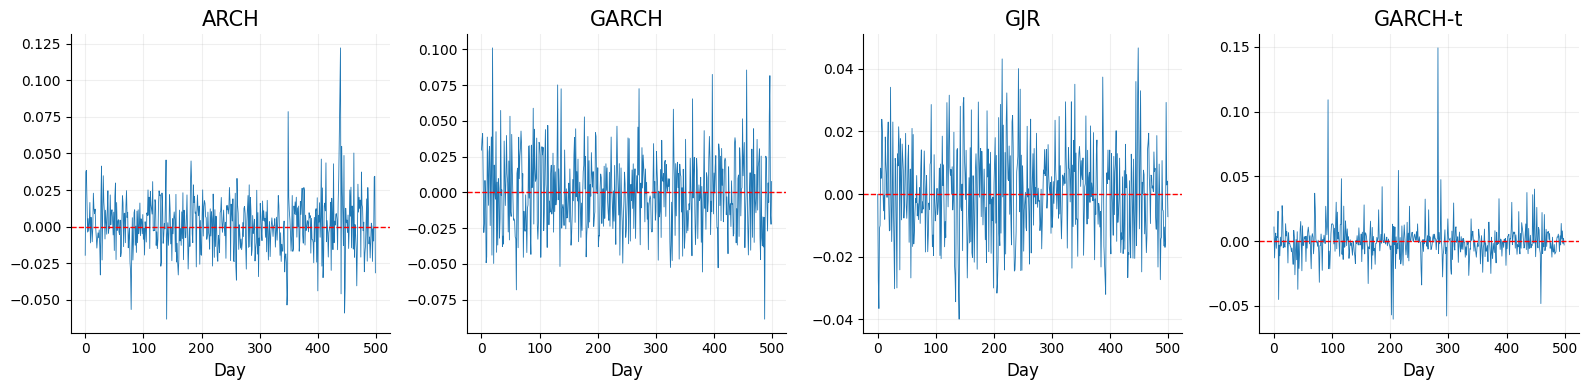

In [33]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)
for ax, sim, name in zip(axes, simulators, model_names):
    path = sim.sample((5,))["returns"][4, :]
    sns.lineplot(path, linewidth=0.6, ax=ax, legend=False)
    ax.grid(alpha=0.2)
    ax.set_title(name, fontsize=15)
    ax.set_xlabel("Day", fontsize=12)
    ax.axhline(0, color="red", linewidth=1, linestyle="--")
    sns.despine()
plt.tight_layout()

### Workflow Setup

Next, we define our `ModelComparisonWorkflow` for the GARCH models. As summary network, we choose a `TimeSeriesTransformer`, which is well suited to summarize sequential data. We train with the default `CrossEntropyScore`. Swapping in `BrierScore()` or `PolynomialScore(alpha=3.0)` would require no change to the workflow other than the `scoring_rules` argument.

We also pass `model_names`. This argument is purely cosmetic: the labels are stored on the workflow and forwarded to every diagnostic plot — confusion-matrix axes, calibration-panel titles, legends — in place of the default $M_1, M_2, \dots$. It has no effect whatsoever on training, on the adapter, or on the estimates themselves; it just makes the diagnostics readable in the models' own names.

In [34]:
pmp_workflow = ModelComparisonWorkflow(
    simulator=simulators,
    summary_variables="returns",
    summary_network=bf.networks.TimeSeriesTransformer(),
    scoring_rules=bf.scoring_rules.CrossEntropyScore(),
    model_names=model_names,
    standardize=["summary_variables"]
)

In [35]:
history = pmp_workflow.fit_online(
    epochs=50,
    num_batches_per_epoch=100,
    batch_size=64,
)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 4.3627 - scoring_rule/inference_scoring_rule: 4.3627  
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 1.7414 - scoring_rule/inference_scoring_rule: 1.7414
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 1.6627 - scoring_rule/inference_scoring_rule: 1.6627
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 1.7054 - scoring_rule/inference_scoring_rule: 1.7054
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 1.6285 - scoring_rule/inference_scoring_rule: 1.6285
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 1.6304 - scoring_rule/inference_scoring_rule: 1.6304
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 1.4252 - scoring_rule/inference_scoring_rule: 1.4252
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 1.4742 - scoring_rule/inference_scoring_rule: 1.4742
Epoch 9/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 1.4958 - scoring_rule/inf

INFO:bayesflow:Training completed in 2.97 minutes.


### Diagnostics

`plot_default_diagnostics` works for both scoring rule families — it detects the active rule and automatically selects the appropriate plots. Here, with a PMP rule, it produces a loss curve, a confusion matrix, and calibration curves.

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Estimation completed in 0.16 seconds.


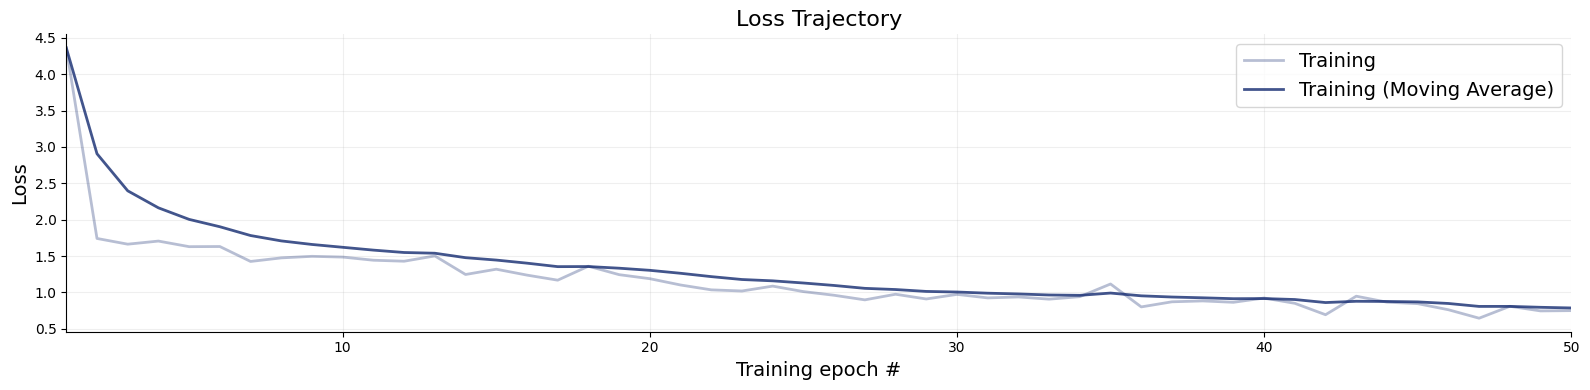

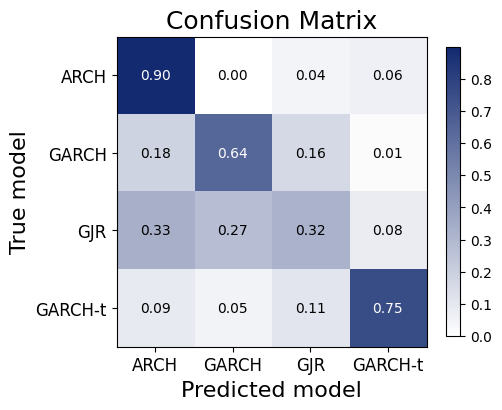

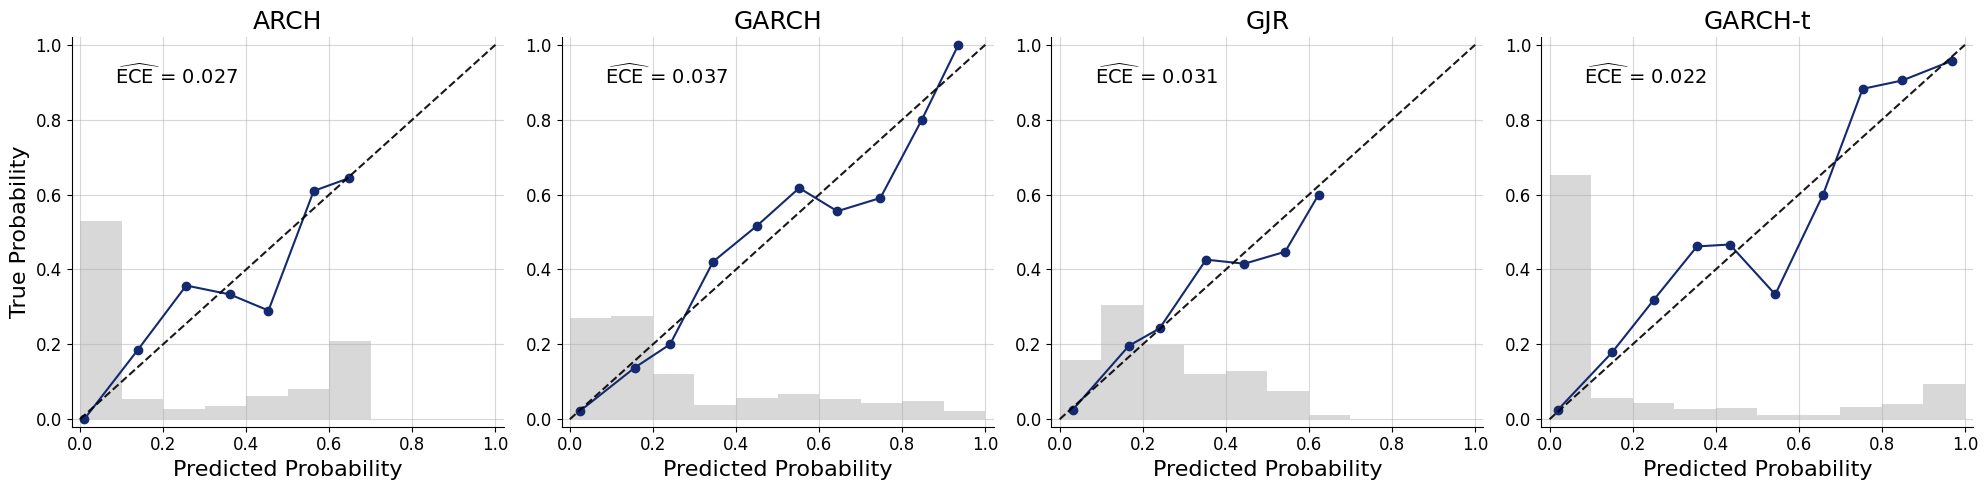

In [36]:
figures = pmp_workflow.plot_default_diagnostics(test_data=500)

Let us read the three diagnostics in turn.

- **Loss.** Unlike the noisy exponential loss in the normal-normal example, the cross-entropy loss here descends smoothly, indicating that training has converged and the classifier has learned to extract discriminative structure from the return series.

- **Confusion matrix.** The results largely reflect the structural relationships between the models — though not in the way one might naively guess. **ARCH** and **GARCH-t** are both identified reliably: ARCH stands out because its zero-persistence dynamics produce a qualitatively different volatility profile, and GARCH-t is betrayed by its heavy-tailed innovations ($\nu \in [2.5, 4.5]$), whose occasional extreme returns leave an unmistakable fingerprint. The genuinely difficult pair is not GARCH vs. GARCH-t but **GJR vs. GARCH**: GJR is most often mistaken for plain GARCH. This makes sense — the only thing separating them is the leverage effect, an *asymmetric* response to negative shocks that reveals itself just during large downward moves, which are rare in a 500-step series with these priors. A residual smear of ARCH ↔ GARCH/GJR confusion appears for the same reason in reverse: datasets in which the persistent models happen to show little volatility clustering look ARCH-like.

- **Calibration.** All four reliability curves stay close to the diagonal, with ECEs between $\approx 0.02$ and $0.05$ — so despite the GJR/GARCH confusion, the reported probabilities are honest: when the network says a series is 60% likely to be GJR, it is right about 60% of the time. The largest wobbles sit in the high-probability bins, where confident predictions are common but individual bins hold few datasets, making the empirical frequency noisier. Overall, the network expresses its uncertainty about the leverage effect as graded probabilities rather than overconfident misclassifications.

## Combining Multiple Scoring Rules at Once

Every workflow so far has used a *single* scoring rule. But `ModelComparisonWorkflow` accepts **several at once** — pass a list (or a `{name: rule}` dict) and it attaches one prediction head per rule on top of the shared summary network, trains them jointly, and **pools** their outputs into a single set of estimates (a log opinion pool over the model log-odds).

Why reach for more than one rule? Three reasons:

- **Robustness through ensembling.** Every proper scoring rule is minimized *in expectation* by the true posterior, but on finite data and finite optimization each settles in a slightly different place, with its own bias–variance profile. `CrossEntropyScore` penalizes wrong probabilities logarithmically, `BrierScore` quadratically, `PolynomialScore` with a tunable exponent. Averaging several proper rules cancels part of that idiosyncratic error, much as an ensemble of classifiers beats its individual members.

- **Two target quantities from one network.** Mixing a *PMP* rule with a *Bayes factor* rule yields both quantities simultaneously — bounded, ready-to-rank posterior model probabilities **and** interpretable pairwise log Bayes factors — from a single training run. You no longer have to commit to one representation before training.

- **A richer, self-consistent diagnostic picture.** With both families present, the default diagnostics report *both* the PMP confusion matrix and the pairwise-BF heatmap, so the two views can be cross-checked against each other.

We reuse the GARCH simulators, priors, summary network, and `model_names` from the previous section **unchanged** — the only thing that changes is the `scoring_rules` argument, now a list combining a PMP rule (`CrossEntropyScore`) and a Bayes factor rule (`LogisticScore`).

In [37]:
multi_rule_workflow = ModelComparisonWorkflow(
    simulator=simulators,
    summary_variables="returns",
    summary_network=bf.networks.TimeSeriesTransformer(),
    scoring_rules=[
        bf.scoring_rules.CrossEntropyScore(),  # PMP rule -> posterior model probabilities
        bf.scoring_rules.LogisticScore(),      # BF rule  -> pairwise log Bayes factors
    ],
    model_names=model_names,
    standardize=["summary_variables"],
)

In [38]:
history = multi_rule_workflow.fit_online(
    epochs=50,
    num_batches_per_epoch=100,
    batch_size=64,
)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - cross_entropy_score/inference_cross_entropy_score: 2.6201 - logistic_score/inference_logistic_score: 2.1043 - loss: 2.3622  
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - cross_entropy_score/inference_cross_entropy_score: 1.8515 - logistic_score/inference_logistic_score: 2.0558 - loss: 1.9536
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - cross_entropy_score/inference_cross_entropy_score: 1.9909 - logistic_score/inference_logistic_score: 2.1302 - loss: 2.0606
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - cross_entropy_score/inference_cross_entropy_score: 1.8117 - logistic_score/inference_logistic_score: 2.0935 - loss: 1.9526
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - cross_entropy_score/inference_cross_entropy_score: 1.5226 - logistic_score/inference_logistic_score: 2.2013 - loss: 1.8620
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - cross_entropy_score/inference_cross_entropy_score: 1.

INFO:bayesflow:Training completed in 2.95 minutes.


### Diagnostics with multiple scoring rules

With **both** families active, `plot_default_diagnostics` detects that a PMP rule *and* a Bayes factor rule are present and draws the confusion matrix (from the pooled PMPs) and the pairwise log-Bayes-factor heatmap (from the pooled log-BFs) **side by side in a single figure**, followed by the calibration curves. Every plot runs on the *pooled* estimates, so it reflects the ensemble rather than any single head.

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Estimation completed in 0.14 seconds.
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode


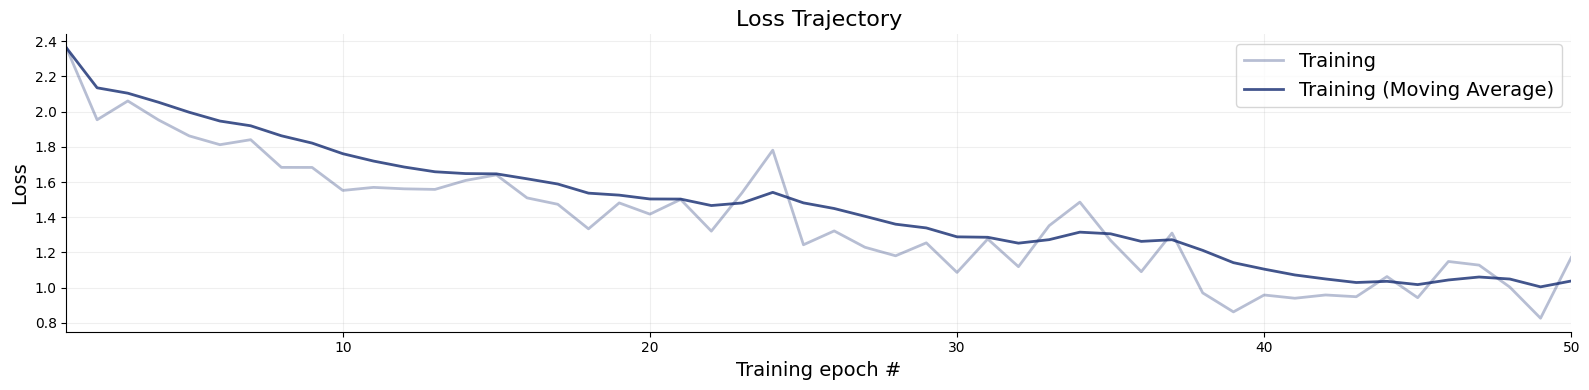

INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode


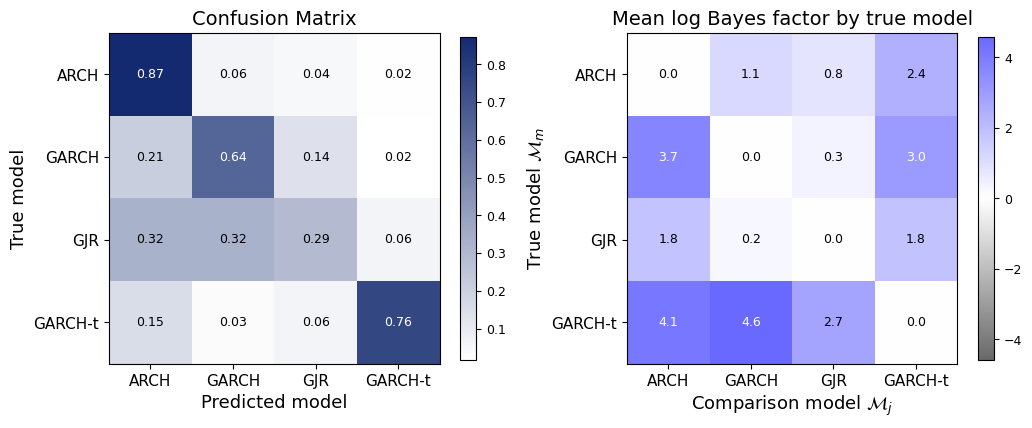

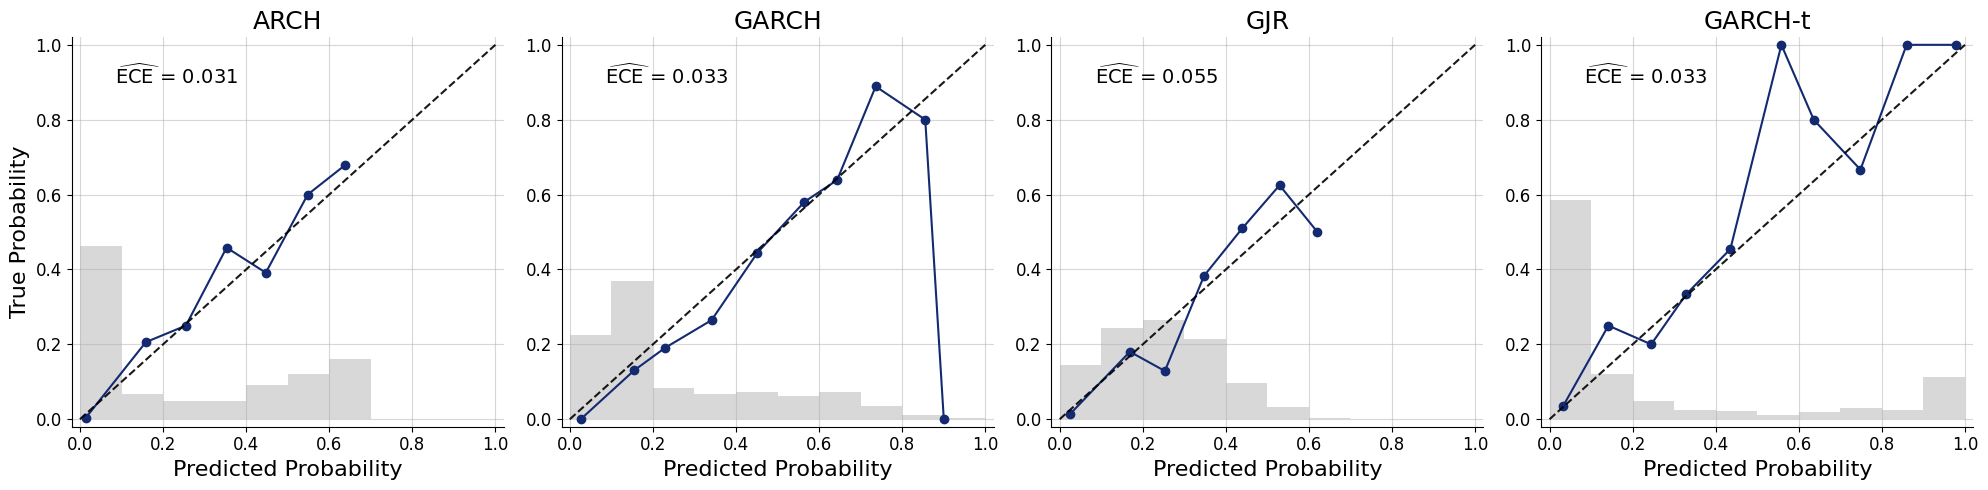

In [39]:
figures = multi_rule_workflow.plot_default_diagnostics(test_data=500)

In [40]:
multi_rule_workflow.compute_default_diagnostics(test_data=500)

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Estimation completed in 0.13 seconds.


,ARCH,GARCH,GJR,GARCH-t
Accuracy,0.844828,0.592857,0.255639,0.729730
Expected Calibration Error,0.023203,0.030709,0.022823,0.023711
Brier Score,0.118880,0.147830,0.175291,0.073981


**What do the combined diagnostics tell us?**

- **Confusion matrix (left).** Because the pooled PMPs blend two proper rules, the classification structure closely mirrors the single-`CrossEntropyScore` run: ARCH and GARCH-t are recovered most reliably, while **GJR is still most easily mistaken for plain GARCH** — the leverage effect remains the subtle, rarely-triggered feature it was before. Pooling does not manufacture information the return series does not contain; what it buys is lower-variance probability estimates, which typically shows up as a slightly cleaner diagonal and less run-to-run wobble, not a qualitatively different matrix.

- **Pairwise log Bayes factors (right).** Each row $m$ shows the mean $\log\mathrm{BF}_{m,j}$ over datasets truly generated by model $m$: positive (blue) off-diagonal entries mean the network correctly accumulates evidence *for* the true model against alternative $j$, and the diagonal is zero by construction. Well-separated pairs (ARCH against anything) produce large positive entries, whereas the **GJR row against GARCH sits closest to zero** — the very same weak-separation story the confusion matrix tells, now expressed on the interpretable evidence scale instead of as probabilities. That the two panels agree is exactly the cross-check the combined view is meant to provide.

- **Calibration and scalar metrics.** The reliability curves and the `Accuracy` / `Expected Calibration Error` / `Brier Score` table are likewise computed from the pooled probabilities, so the per-model accuracies should track the confusion-matrix diagonal and the ECEs should stay small. If anything, the ensemble's Brier score and ECE tend to come out marginally better than either rule alone — the concrete, if modest, payoff of combining scoring rules.

The larger point: we obtained *all* of this — probabilities **and** Bayes factors, both sets of diagnostics — from a **single** trained network. That is the practical appeal of combining scoring rules: you are no longer forced to choose your target quantity before training, and you get an ensemble's robustness for free.

Congratulations! Through this deep-dive notebook, you have seen all the central aspects of BayesFlow's `ModelComparisonWorkflow`. Now, go ahead and compare your models!